In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


In [2]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



Text(0.5, 1.0, 'Animal #2 Cell #4')

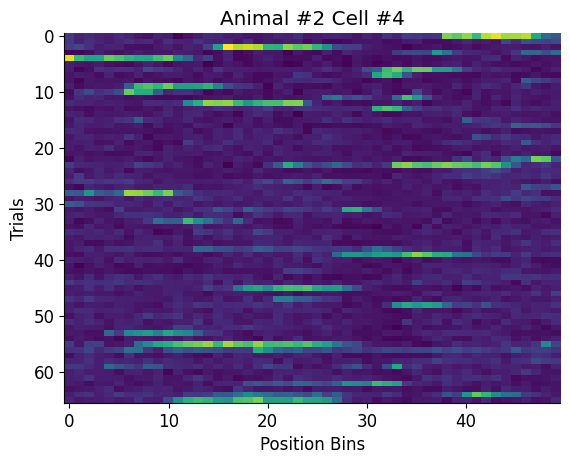

In [4]:
example_EC_cell = residual_activity_dict_EC['animal_2']['cell_4']
plt.imshow(example_EC_cell.T, aspect='auto')
plt.xlabel("Position Bins")
plt.ylabel("Trials")
plt.title("Animal #2 Cell #4")

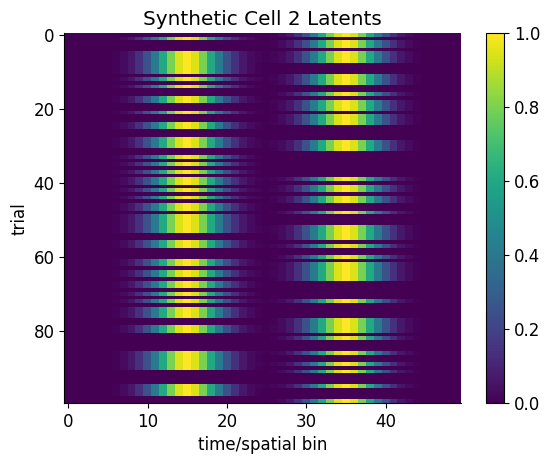

In [5]:


ideal_cell = get_ideal_random_cell(num_trials=100, num_timebins=50)


The model converged. Loss: 2.0501622202573344e-05 :   7%|▋         | 1109/15000 [00:02<00:33, 412.60it/s]
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:15: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3641.)
  latents = torch.abs(model.vectors[0][1].detach().T).cpu().numpy()


(100, 2)
(50, 2)


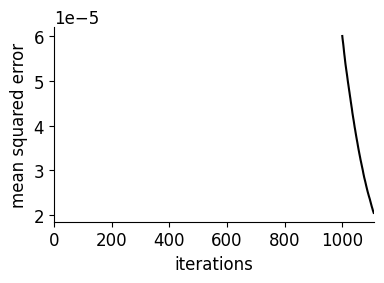

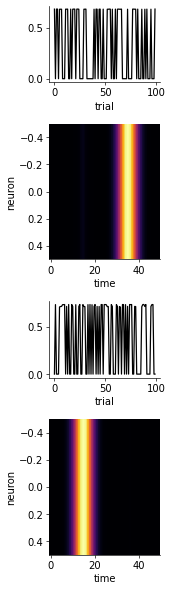

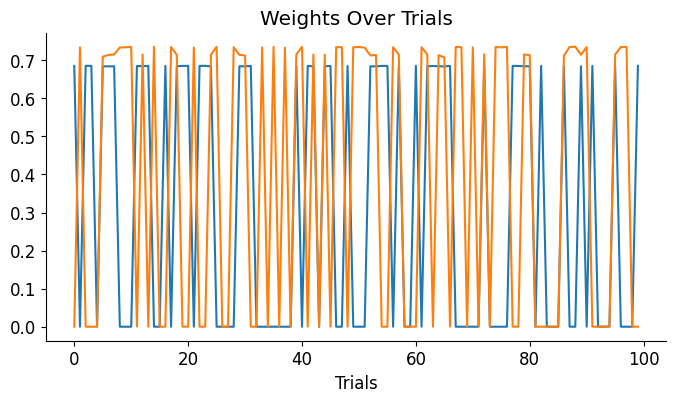

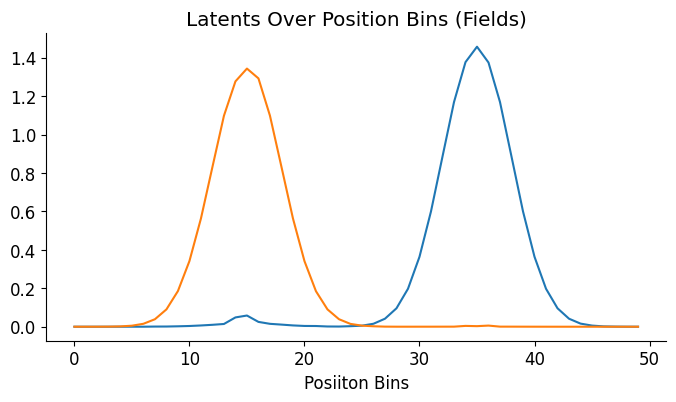

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


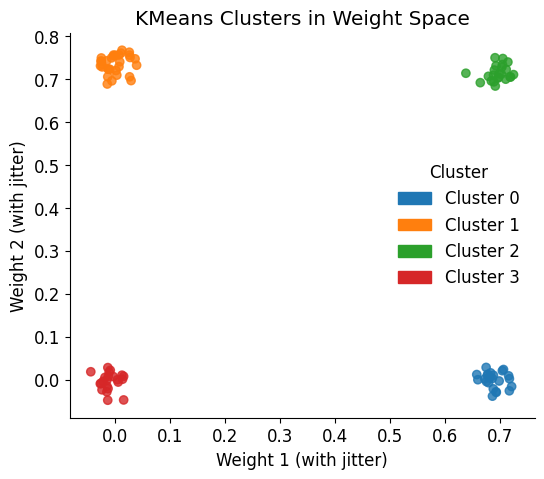

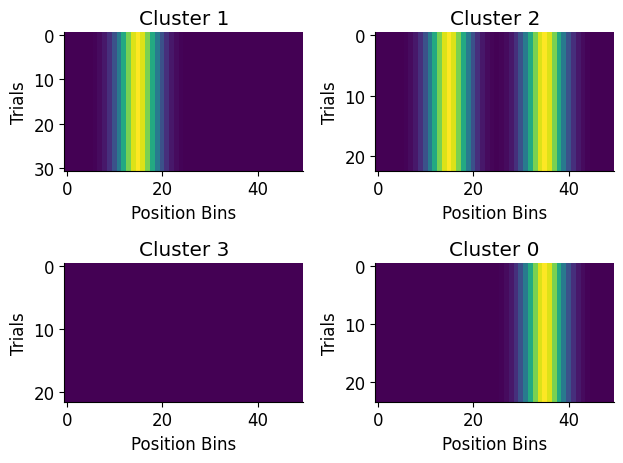

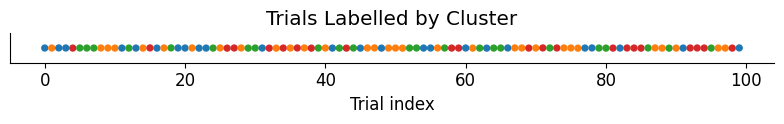

In [6]:
model = run_slice_tca_ideal_ex(ideal_cell)
plot_synthetic_sliceTCA_ex(model, ideal_cell)

In [7]:
################ using a real EC cell #######################

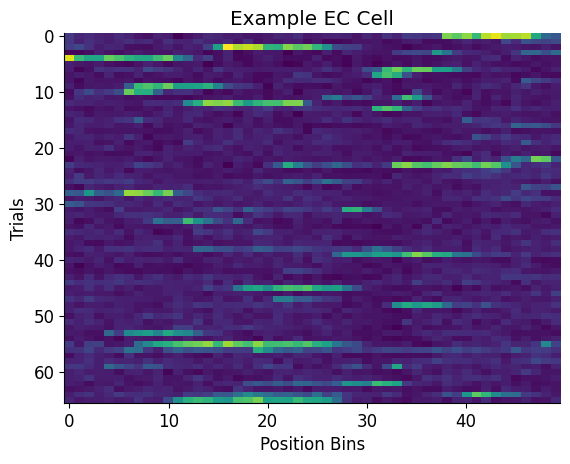

In [8]:

example_EC_cell = residual_activity_dict_EC['animal_2']['cell_4']
plt.imshow(example_EC_cell.T, aspect='auto')
plt.title("Example EC Cell")
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.show()


In [9]:

example_EC_cell_tensor = torch.from_numpy(example_EC_cell).unsqueeze(axis=1)
example_EC_cell_tensor = example_EC_cell_tensor.permute(2, 1, 0)
print(example_EC_cell_tensor.shape)  # should now be torch.Size([78, 1, 50])

# components_2, model_2 = slicetca.decompose(example_EC_cell_tensor,
#                                        number_components=(2,0,0), # (trials, neurons, time bins)
#                                        positive=False,
#                                        learning_rate=1*10**-3,
#                                        min_std=10**-5,
#                                        max_iter=15_000,
#                                        seed=0)


components_20, model_20 = slicetca.decompose(example_EC_cell_tensor,
                                       number_components=(20,0,0), # (trials, neurons, time bins)
                                       positive=False,
                                       learning_rate=1*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)

# components_60, model_60 = slicetca.decompose(example_EC_cell_tensor,
#                                        number_components=(60,0,0), # (trials, neurons, time bins)
#                                        positive=False,
#                                        learning_rate=1*10**-3,
#                                        min_std=10**-5,
#                                        max_iter=15_000,
#                                        seed=0)

torch.Size([66, 1, 50])


The model converged. Loss: 0.01758905779038221 :  38%|███▊      | 5693/15000 [00:28<00:45, 203.19it/s]


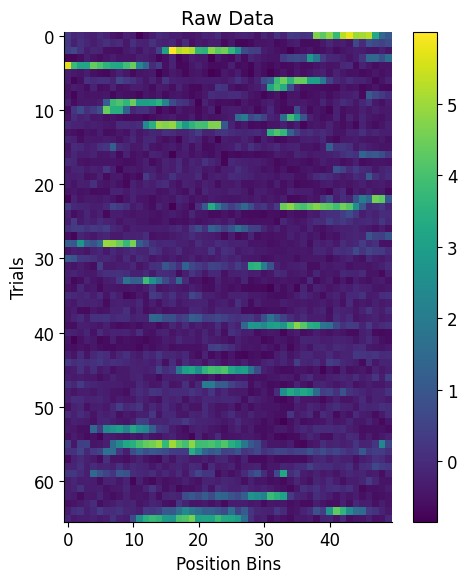

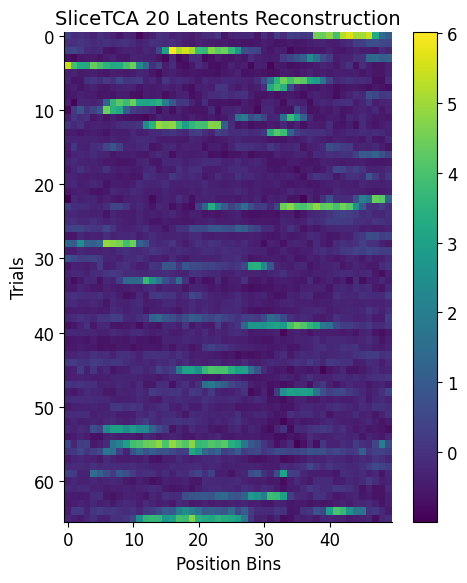

In [10]:

# plot_model_vs_reco(example_EC_cell_tensor, model_60, x=60)
plot_model_vs_reco(example_EC_cell_tensor, model_20, x=20)
# plot_model_vs_reco(example_EC_cell_tensor, model_2, x=2)


In [11]:
################ clusters must be of size 3+

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]
        

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

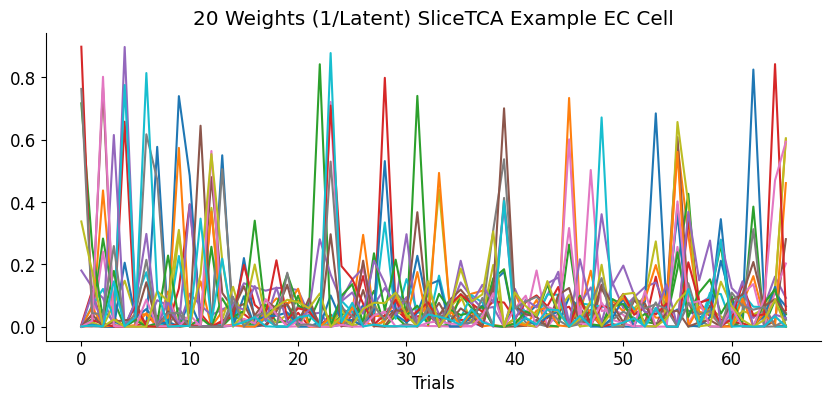

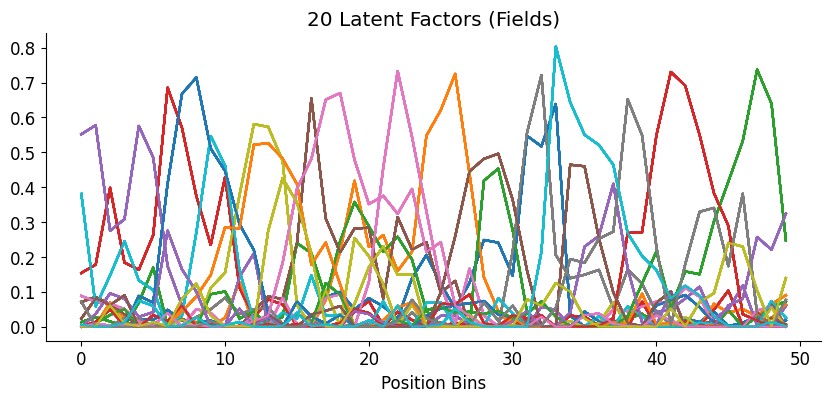

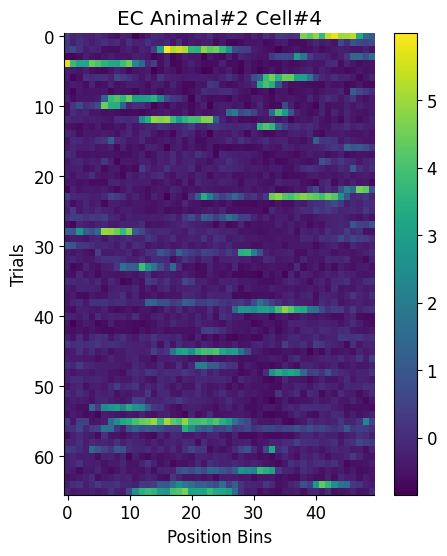

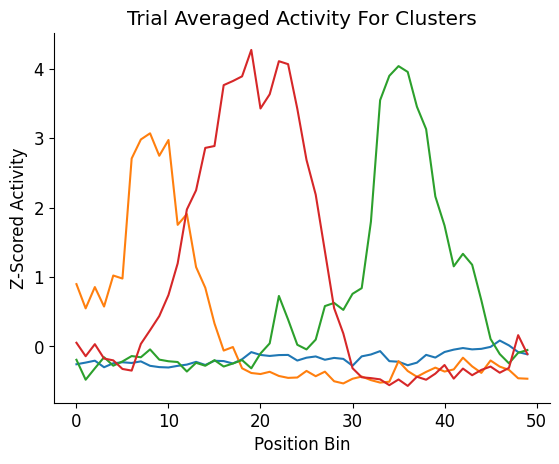

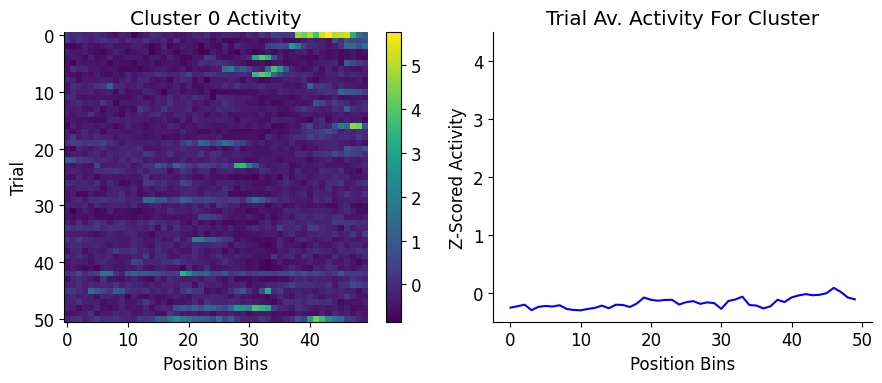

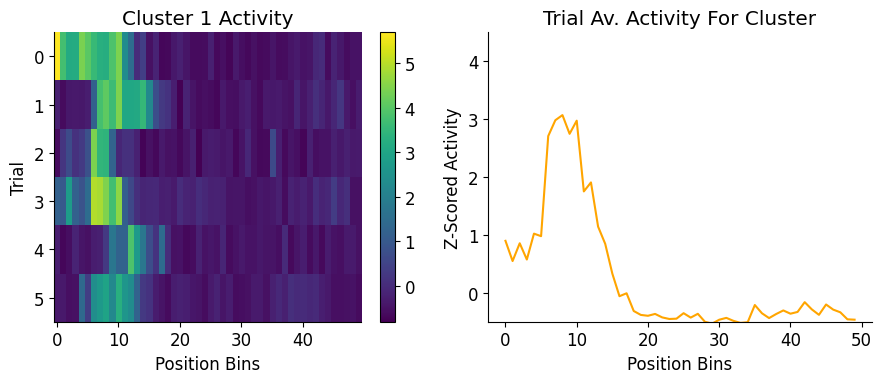

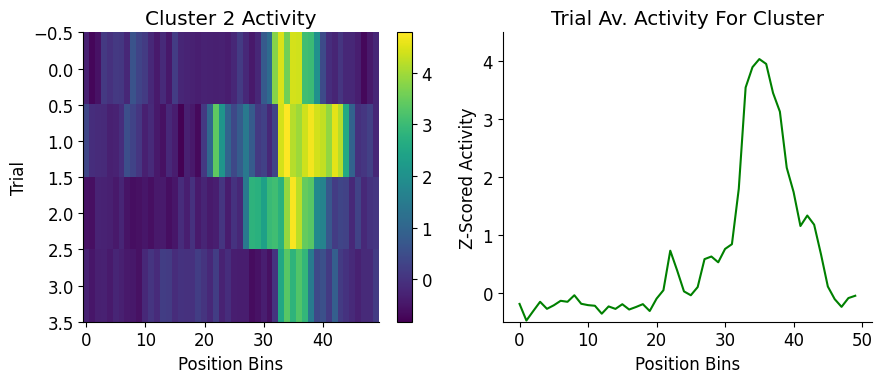

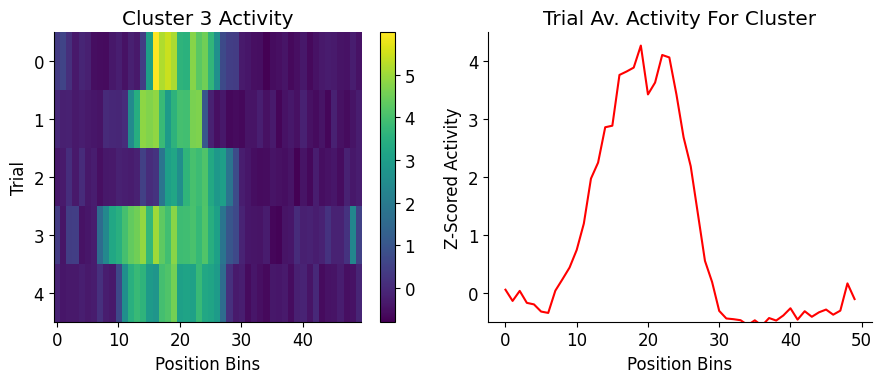

In [12]:


animal_choice=1
cell_choice=3


plot_example_weights_latents_real(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_choice, cell=cell_choice)

d = residual_activity_dict_EC['animal_2']['cell_4']
plt.figure(figsize=(5,6))
plt.imshow(d.T, aspect='auto')
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.title("EC Animal#2 Cell#4")
plt.colorbar()
plt.show()

plot_real_activity_clusters(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal=animal_choice, cell=cell_choice)

In [13]:
########### uncomment if you want to generate the data - for time sake I would just load files

##### same as below but experimenting with middle 

# clusters_dict_SST_early = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="early")
# clusters_dict_SST_late = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="late")
# clusters_dict_SST_overall = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")
# clusters_dict_SST_middle = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="middle")

# clusters_dict_EC_early = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="early")
# clusters_dict_EC_late = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="late")
# clusters_dict_EC_overall = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
# clusters_dict_EC_middle = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="middle")

# clusters_dict_NDNF_early = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="early")
# clusters_dict_NDNF_late = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="late")
# clusters_dict_NDNF_overall = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")
# clusters_dict_NDNF_middle = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="middle")



import pickle

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_early.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_early = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_late.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_late = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_overall.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_SST_overall = pickle.load(f)
    
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_SST_middle.pkl" 
with open(file_path, 'rb') as f:
    clusters_dict_SST_middle = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_EC_middle.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_EC_middle = pickle.load(f)

file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/clusters_dict_NDNF_middle.pkl"
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_middle = pickle.load(f)



In [14]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells'
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells'
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

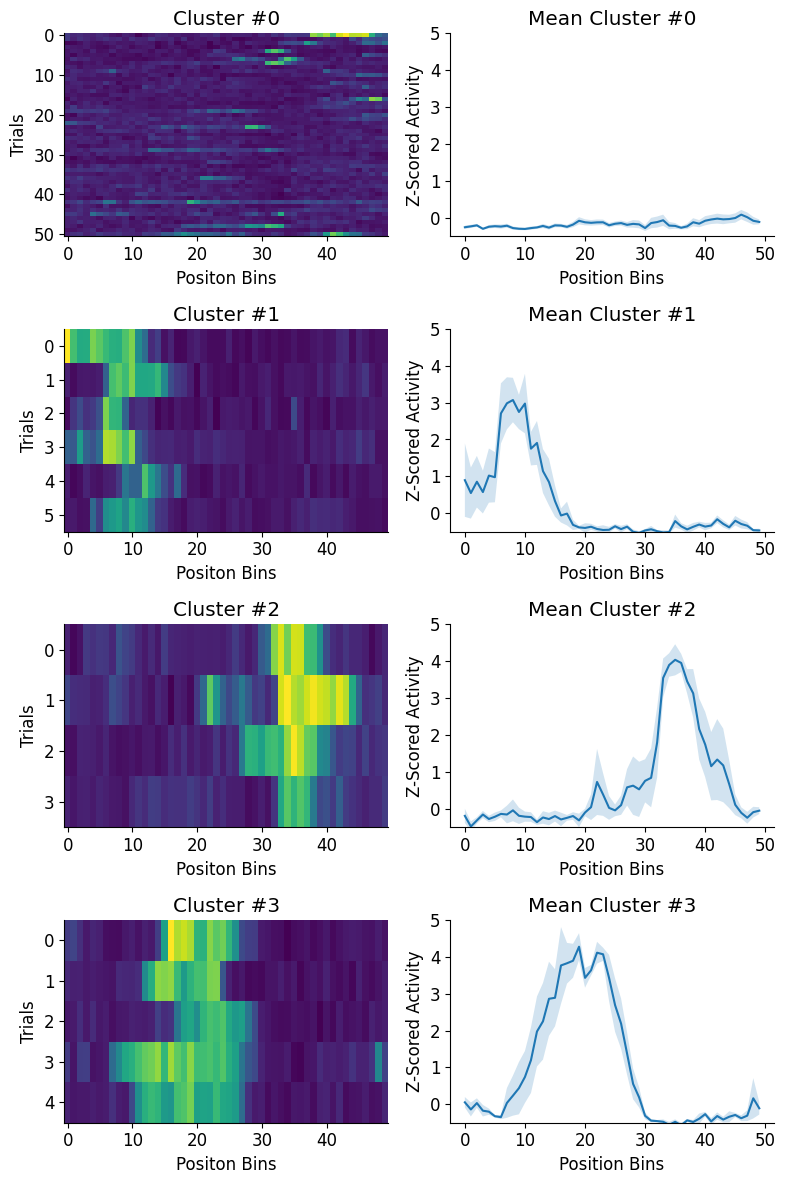

In [32]:

def get_activity_array(activity, ax, i):
    ax.imshow(activity.T, aspect='auto')
    ax.set_xlabel("Positon Bins")
    ax.set_title(f"Cluster #{i}")
    ax.set_ylabel("Trials")

def get_mean_activity_array(activity, ax, i):
    mean_activity = np.mean(activity, axis=1)
    sem_activity = sem(activity, axis=1)
    ax.plot(mean_activity)
    ax.set_ylim(-0.5, 5)
    ax.set_ylabel("Z-Scored Activity")
    ax.set_title(f"Mean Cluster #{i}")
    ax.set_xlabel("Position Bins")
    ax.fill_between(range(len(mean_activity)), mean_activity+sem_activity, mean_activity-sem_activity, alpha=0.2)


activity_list = []
for i in activity_indices_EC_dict['animal_2']['cell_4']:
    activity = activity_indices_EC_dict['animal_2']['cell_4'][i]['activity']
    activity_list.append(activity)



fig, axs = plt.subplots(4,2, figsize=(8,12))
get_activity_array(activity_list[0], ax=axs[0,0], i=0)
get_activity_array(activity_list[1], ax=axs[1,0], i=1)
get_activity_array(activity_list[2], ax=axs[2,0], i=2)
get_activity_array(activity_list[3], ax=axs[3,0], i=3)

get_mean_activity_array(activity_list[0], ax=axs[0,1], i=0)
get_mean_activity_array(activity_list[1], ax=axs[1,1], i=1)
get_mean_activity_array(activity_list[2], ax=axs[2,1], i=2)
get_mean_activity_array(activity_list[3], ax=axs[3,1], i=3)
plt.tight_layout()
plt.show()



/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_6570/1072704401.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


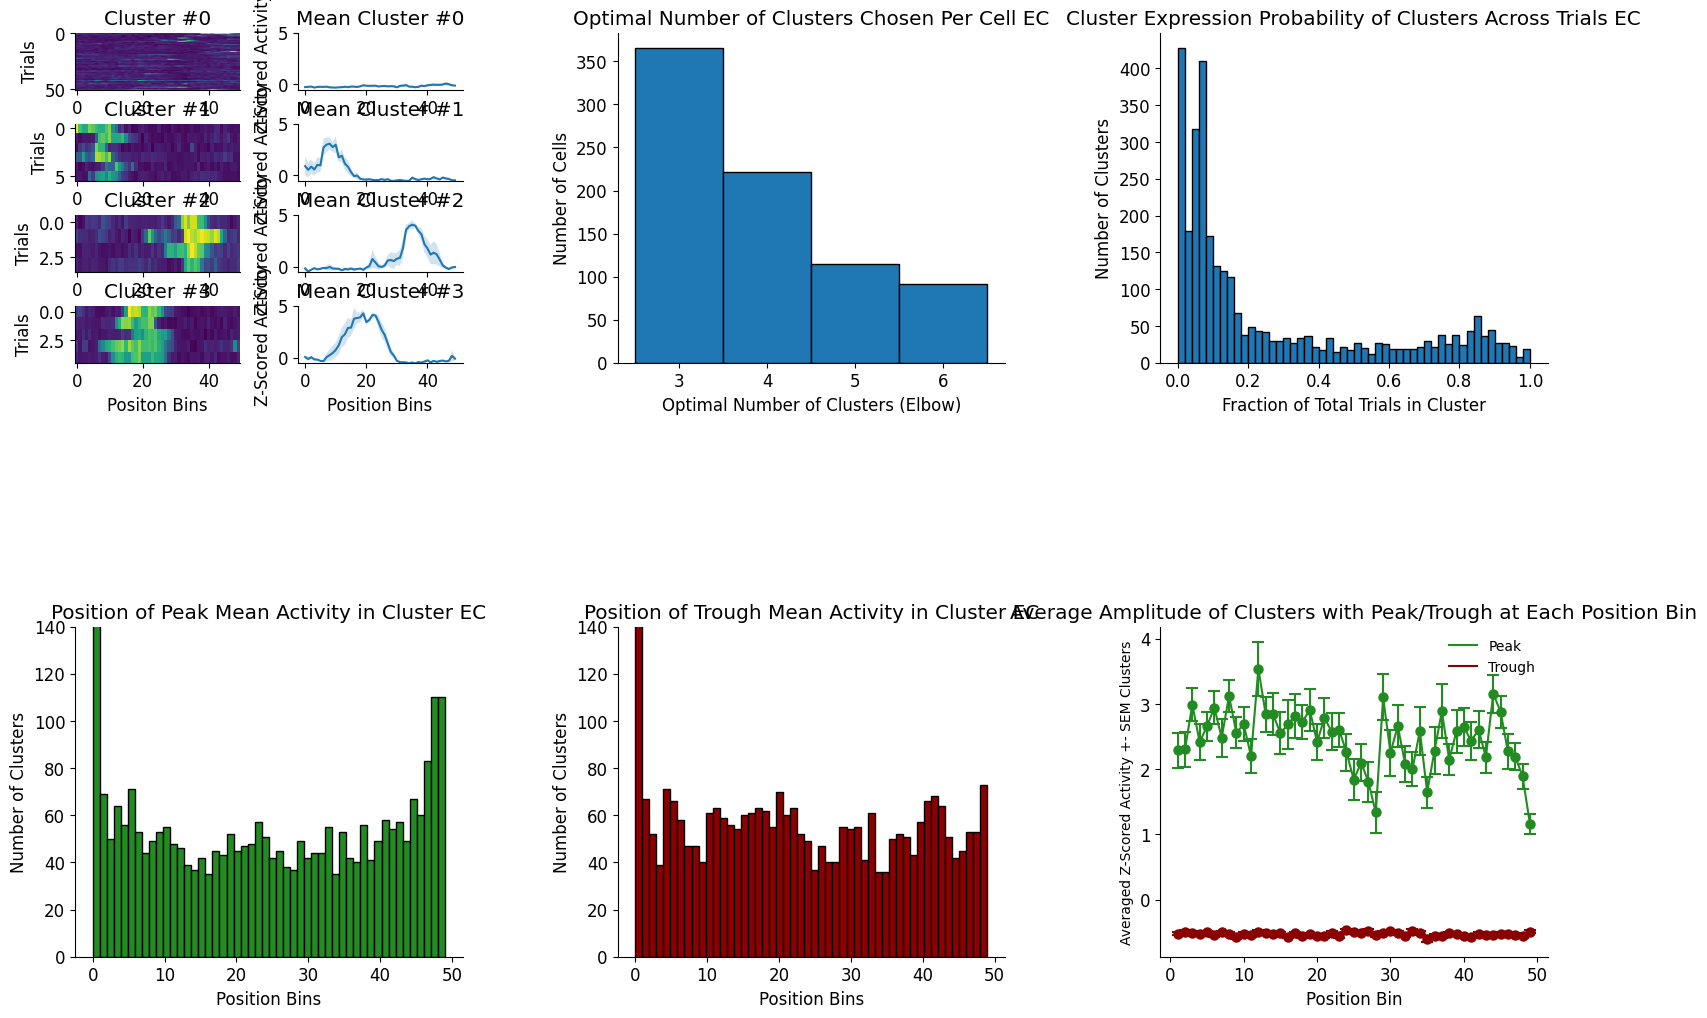

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# If you don’t already have this dict built, do it before plotting:
indices_dict_EC_overall = get_indices_dict(
    cell_EC_model_ranks20_contig_x00,
    testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell,
    residual_activity_dict_EC,
    eln="nothing"
)
activity_indices_EC_dict = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_overall)

# Build the list of activities for the 4 clusters (adjust keys as needed)
activity_list = []
for i in activity_indices_EC_dict['animal_2']['cell_4']:
    activity = activity_indices_EC_dict['animal_2']['cell_4'][i]['activity']
    activity_list.append(activity)

# ---- main figure: 2x3 grid with a nested 4x2 in the top-left ----
fig = plt.figure(figsize=(19, 12))
gs = fig.add_gridspec(nrows=2, ncols=3, hspace=0.8, wspace=0.4)

# Nested grid in [0,0]
subgs = gs[0, 1].subgridspec(nrows=4, ncols=2, hspace=0.6, wspace=0.35)

# Create the 8 nested axes
ax00 = fig.add_subplot(subgs[0, 0])
ax01 = fig.add_subplot(subgs[0, 1])
ax10 = fig.add_subplot(subgs[1, 0])
ax11 = fig.add_subplot(subgs[1, 1])
ax20 = fig.add_subplot(subgs[2, 0])
ax21 = fig.add_subplot(subgs[2, 1])
ax30 = fig.add_subplot(subgs[3, 0])
ax31 = fig.add_subplot(subgs[3, 1])

# Fill the nested 4x2 with your activity and mean plots
get_activity_array(activity_list[0], ax=ax00, i=0)
get_mean_activity_array(activity_list[0], ax=ax01, i=0)

get_activity_array(activity_list[1], ax=ax10, i=1)
get_mean_activity_array(activity_list[1], ax=ax11, i=1)

get_activity_array(activity_list[2], ax=ax20, i=2)
get_mean_activity_array(activity_list[2], ax=ax21, i=2)

get_activity_array(activity_list[3], ax=ax30, i=3)
get_mean_activity_array(activity_list[3], ax=ax31, i=3)

# The rest of the 2x3 cells
ax01_big = fig.add_subplot(gs[0, 0])
ax02_big = fig.add_subplot(gs[0, 2])
ax10_big = fig.add_subplot(gs[1, 0])
ax11_big = fig.add_subplot(gs[1, 1])
ax12_big = fig.add_subplot(gs[1, 2])

# Your existing plotting calls, but send them to the new axes:
plot_optimal_num_clusters_histogram(clusters_dict_EC_overall, title="EC", ylim=None, ax=ax01_big)
plot_cluster_expression_probs(clusters_dict_EC_overall, residual_activity_dict_EC, title="EC", ylim=None, ax=ax02_big)

plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=True,  title="EC", ylim=(0, 140), ax=ax10_big)
plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=False, title="EC", ylim=(0, 140), ax=ax11_big)

plot_means_sems_max_min(activity_indices_EC_dict, ax=ax12_big)

plt.tight_layout()
plt.show()


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


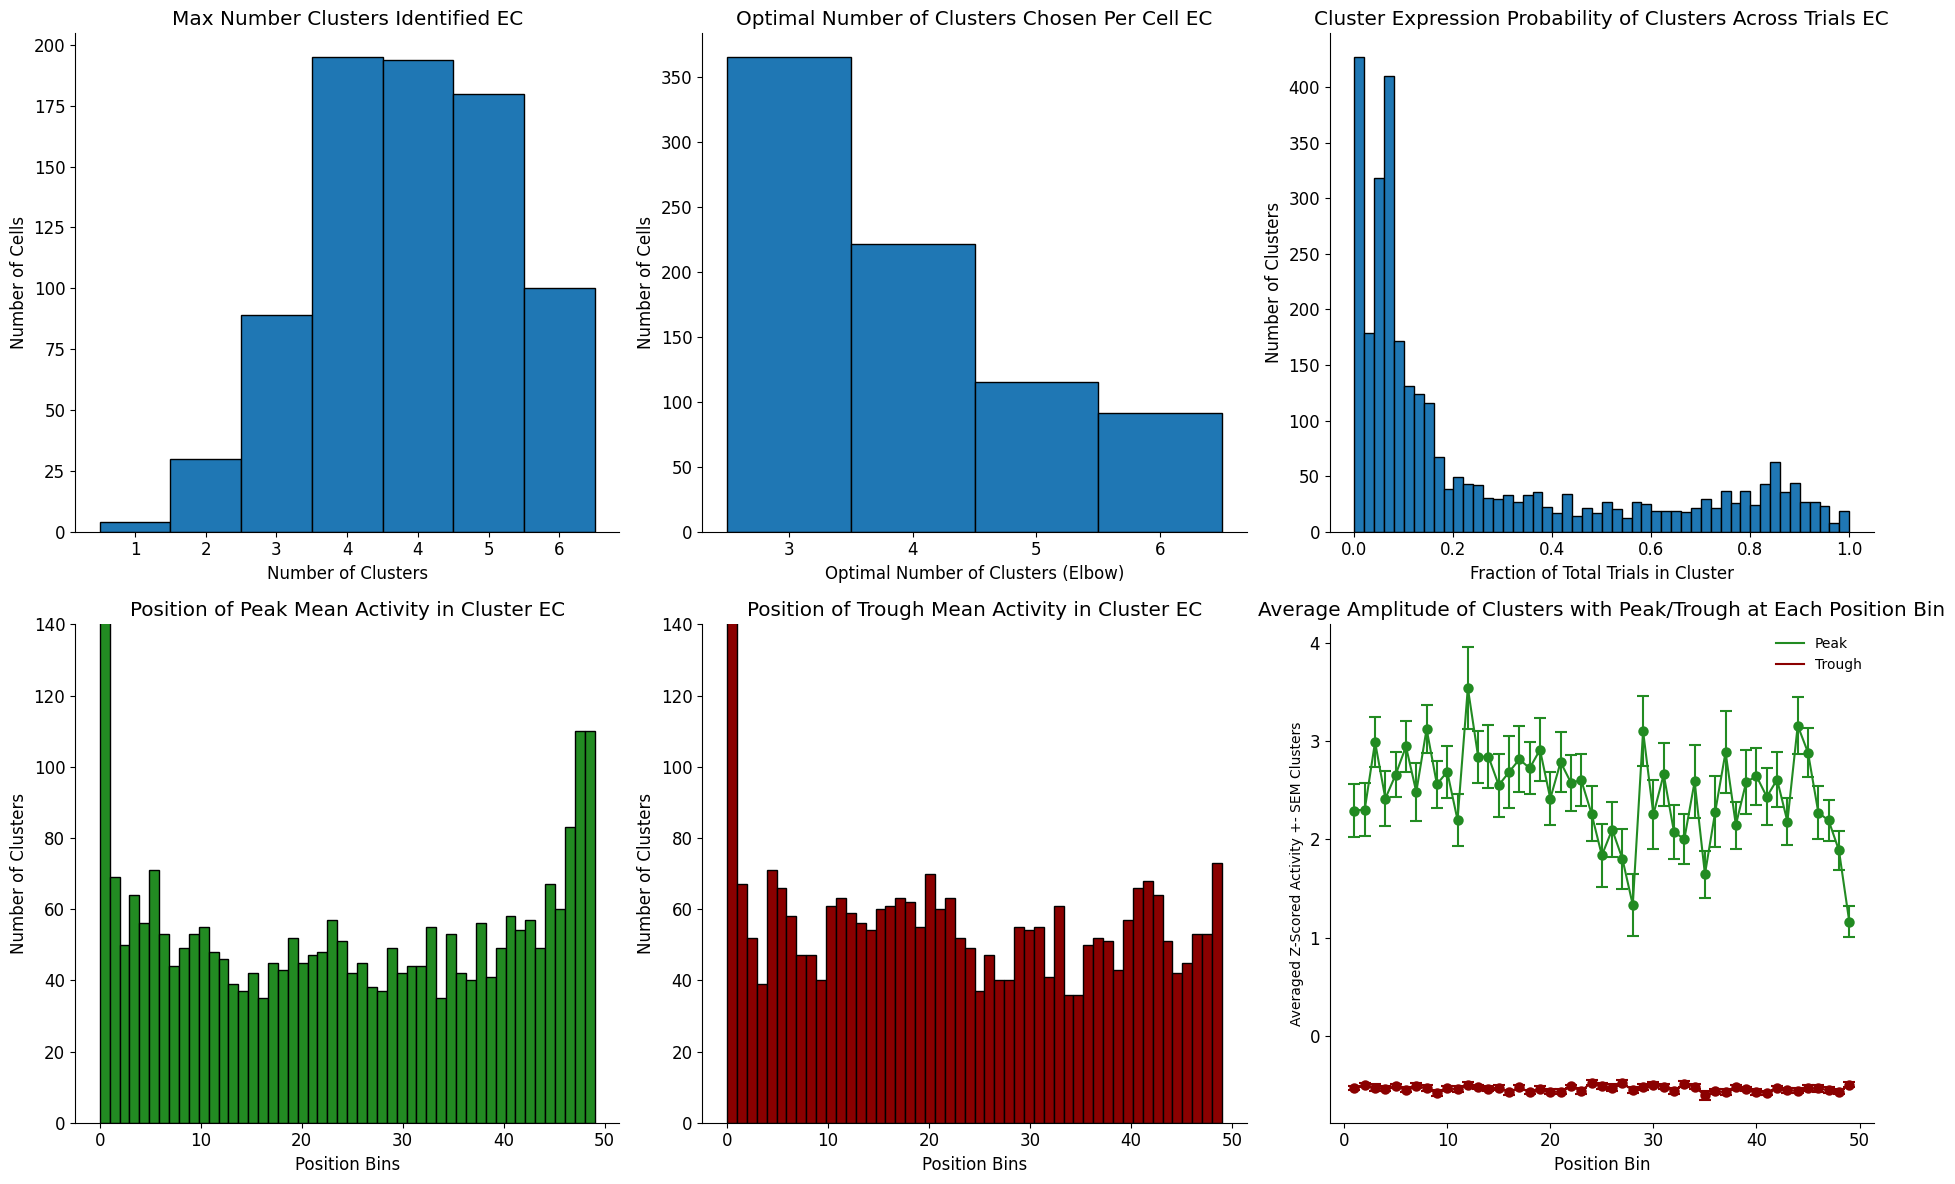

In [ ]:

###################### this plots everything 




fig, axs = plt.subplots(2,3, figsize=(19,12))
plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=True, title="EC", ylim=(0,140), ax=axs[1,0])
plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=False, title="EC", ylim=(0,140), ax=axs[1,1])

indices_dict_EC_overall = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
activity_indices_EC_dict = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_overall)

plot_means_sems_max_min(activity_indices_EC_dict, ax=axs[1,2])
# plot_max_clusters(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, title="EC", ax=axs[0,0])
plot_optimal_num_clusters_histogram(clusters_dict_EC_overall, title="EC", ylim=None, ax=axs[0,1])
plot_cluster_expression_probs(clusters_dict_EC_overall, residual_activity_dict_EC, title="EC", ylim=None, ax=axs[0,2])
plt.tight_layout()
plt.show()



In [ ]:



plot_elbow_cell_example(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=1, cell=1)


KeyError: None

In [ ]:



# ---- your helpers (unchanged) ----
def get_activity_array(activity, ax, i):
    ax.imshow(activity.T, aspect='auto')
    ax.set_xlabel("Positon Bins")
    ax.set_title(f"Ex Cell Cluster #{i}")
    ax.set_ylabel("Trials")

def get_mean_activity_array(activity, ax, i, min=None, max=None):
    from scipy.stats import sem
    mean_activity = np.mean(activity, axis=1)
    sem_activity = sem(activity, axis=1)
    ax.plot(mean_activity)
    ax.set_ylim(min, max)
    ax.set_ylabel("Z-Scored Activity")
    ax.set_title(f"Ex Cell Mean Cluster #{i}")
    ax.set_xlabel("Position Bins")
    ax.fill_between(range(len(mean_activity)),
                    mean_activity + sem_activity,
                    mean_activity - sem_activity,
                    alpha=0.2)




def plot_pop_stats(clusters_dict_EC_overall, cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal=None, cell=None, cell_type="EC", ylim=None):

    fig = plt.figure(figsize=(21, 14), constrained_layout=True)

    indices_dict_EC_overall = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
    activity_indices_EC_dict = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_overall)

    max=0
    min=0
    activity_list = []
    for i in activity_indices_EC_dict[animal][cell]:
        activity = activity_indices_EC_dict[animal][cell][i]['activity']
        activity_list.append(activity)
        if np.max(activity) > max:
            max=np.max(activity)
        if np.min(activity) < min:
            min=np.min(activity)
        

    # --- outer grid: make left column wide, shrink vertical gap between rows ---
    gs = plt.GridSpec(
        2, 3, figure=fig,
        width_ratios=[1.6, 1.6, 1.6],
        height_ratios=[1.0, 1.0]
    )

    # reduce global paddings/gaps for constrained_layout
    # (works in recent Matplotlib; fall back to set_constrained_layout_pads if needed)
    fig.get_layout_engine().set(h_pad=0.03, w_pad=0.01, hspace=0.04, wspace=0.04)

    # --- nested grid in top-left ---
    subgs = gs[0, 0].subgridspec(4, 2, hspace=0.08, wspace=0.03)

    # make nested axes
    ax00 = fig.add_subplot(subgs[0, 0]); ax01 = fig.add_subplot(subgs[0, 1])
    ax10 = fig.add_subplot(subgs[1, 0]); ax11 = fig.add_subplot(subgs[1, 1])
    ax20 = fig.add_subplot(subgs[2, 0]); ax21 = fig.add_subplot(subgs[2, 1])
    ax30 = fig.add_subplot(subgs[3, 0]); ax31 = fig.add_subplot(subgs[3, 1])

    # your plotting...
    get_activity_array(activity_list[0], ax=ax00, i=0); get_mean_activity_array(activity_list[0], ax=ax01, i=0, min=min, max=max)
    get_activity_array(activity_list[1], ax=ax10, i=1); get_mean_activity_array(activity_list[1], ax=ax11, i=1, min=min, max=max)
    get_activity_array(activity_list[2], ax=ax20, i=2); get_mean_activity_array(activity_list[2], ax=ax21, i=2, min=min, max=max)
    get_activity_array(activity_list[3], ax=ax30, i=3); get_mean_activity_array(activity_list[3], ax=ax31, i=3, min=min, max=max)

    # ---- tidy nested labels to save vertical space ----
    for ax in [ax00, ax10, ax20]:           # hide repeated x labels on upper rows
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    for ax in [ax01, ax11, ax21]:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

    # shrink title/label padding inside the nested block
    for ax in [ax00, ax01, ax10, ax11, ax20, ax21, ax30, ax31]:
        ax.set_title(ax.get_title(), fontsize=11, pad=2)
        ax.xaxis.labelpad = 2
        ax.yaxis.labelpad = 2
        ax.tick_params(labelsize=8, pad=1)

    # --- rest of the outer axes ---
    ax_big_01 = fig.add_subplot(gs[0, 1])
    ax_big_02 = fig.add_subplot(gs[0, 2])
    ax_big_10 = fig.add_subplot(gs[1, 0])
    ax_big_11 = fig.add_subplot(gs[1, 1])
    ax_big_12 = fig.add_subplot(gs[1, 2])

    plot_optimal_num_clusters_histogram(clusters_dict_EC_overall, title="EC", ylim=None, ax=ax_big_01)
    plot_cluster_expression_probs(clusters_dict_EC_overall, residual_activity_dict_EC, title=cell_type, ylim=None, ax=ax_big_02)
    plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=True,  title=cell_type, ylim=ylim, ax=ax_big_10)
    plot_peak_trough_histograms(clusters_dict_EC_overall, use_argmax=False, title=cell_type, ylim=ylim, ax=ax_big_11)
    plot_means_sems_max_min(activity_indices_EC_dict, ax=ax_big_12)

    # slightly tighten title pads on the outer plots too
    for ax in [ax_big_01, ax_big_02, ax_big_10, ax_big_11, ax_big_12]:
        ax.set_title(ax.get_title(), pad=6)

    plt.show()




/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


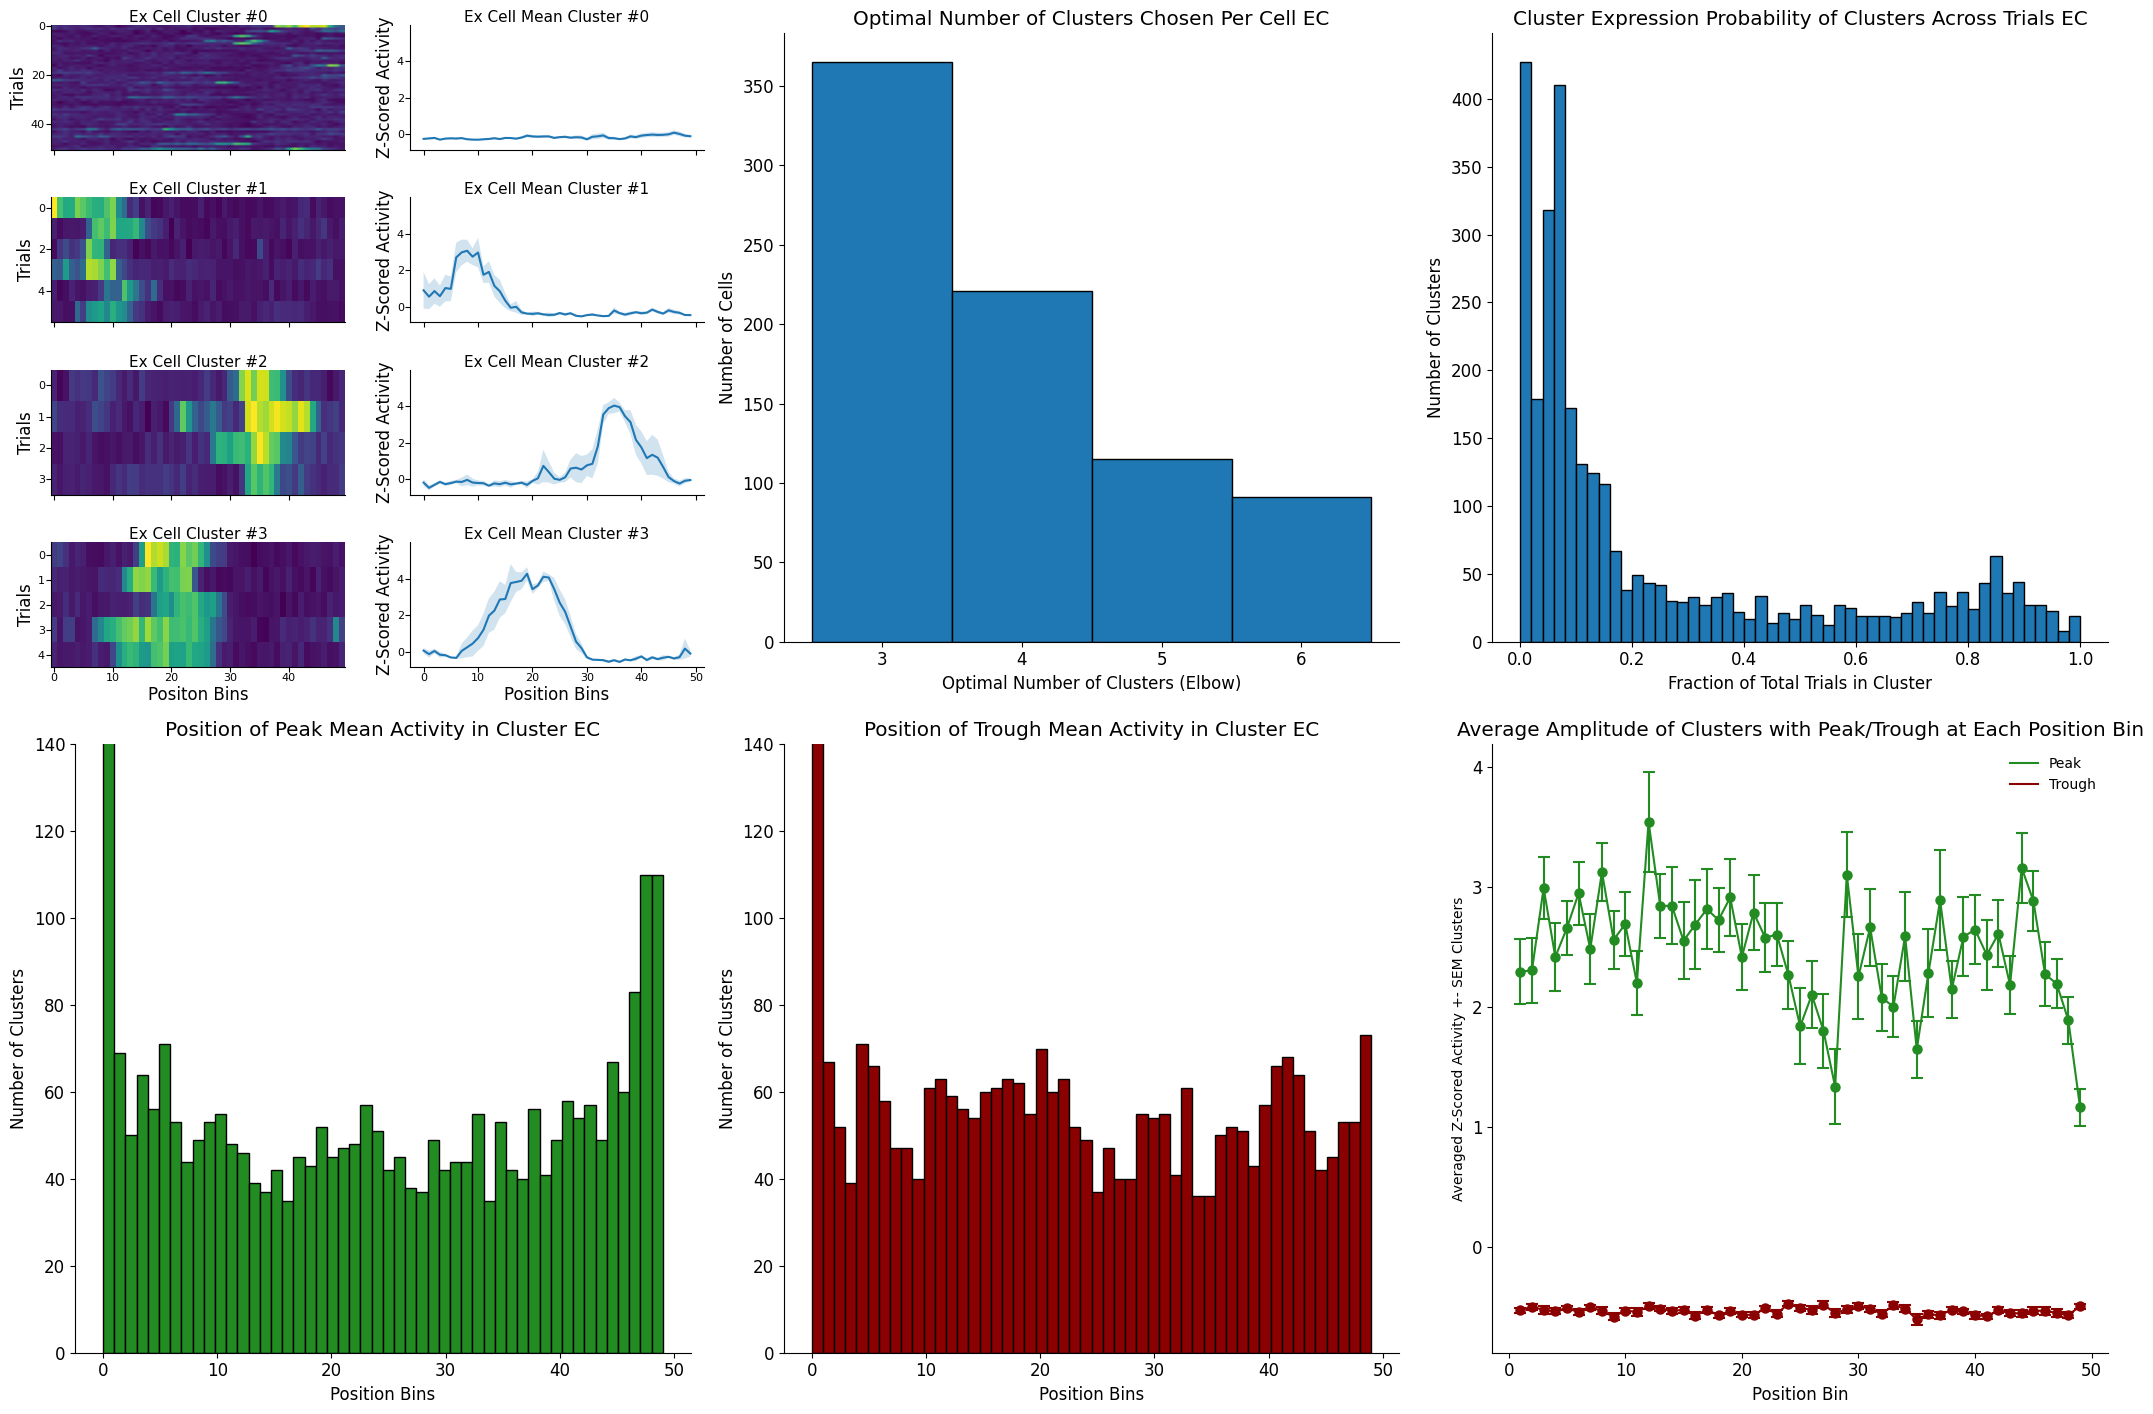

In [72]:
plot_pop_stats(clusters_dict_EC_overall, cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, cell_type="EC", animal='animal_2', cell='cell_4', ylim=(0,140))

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:521: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sa

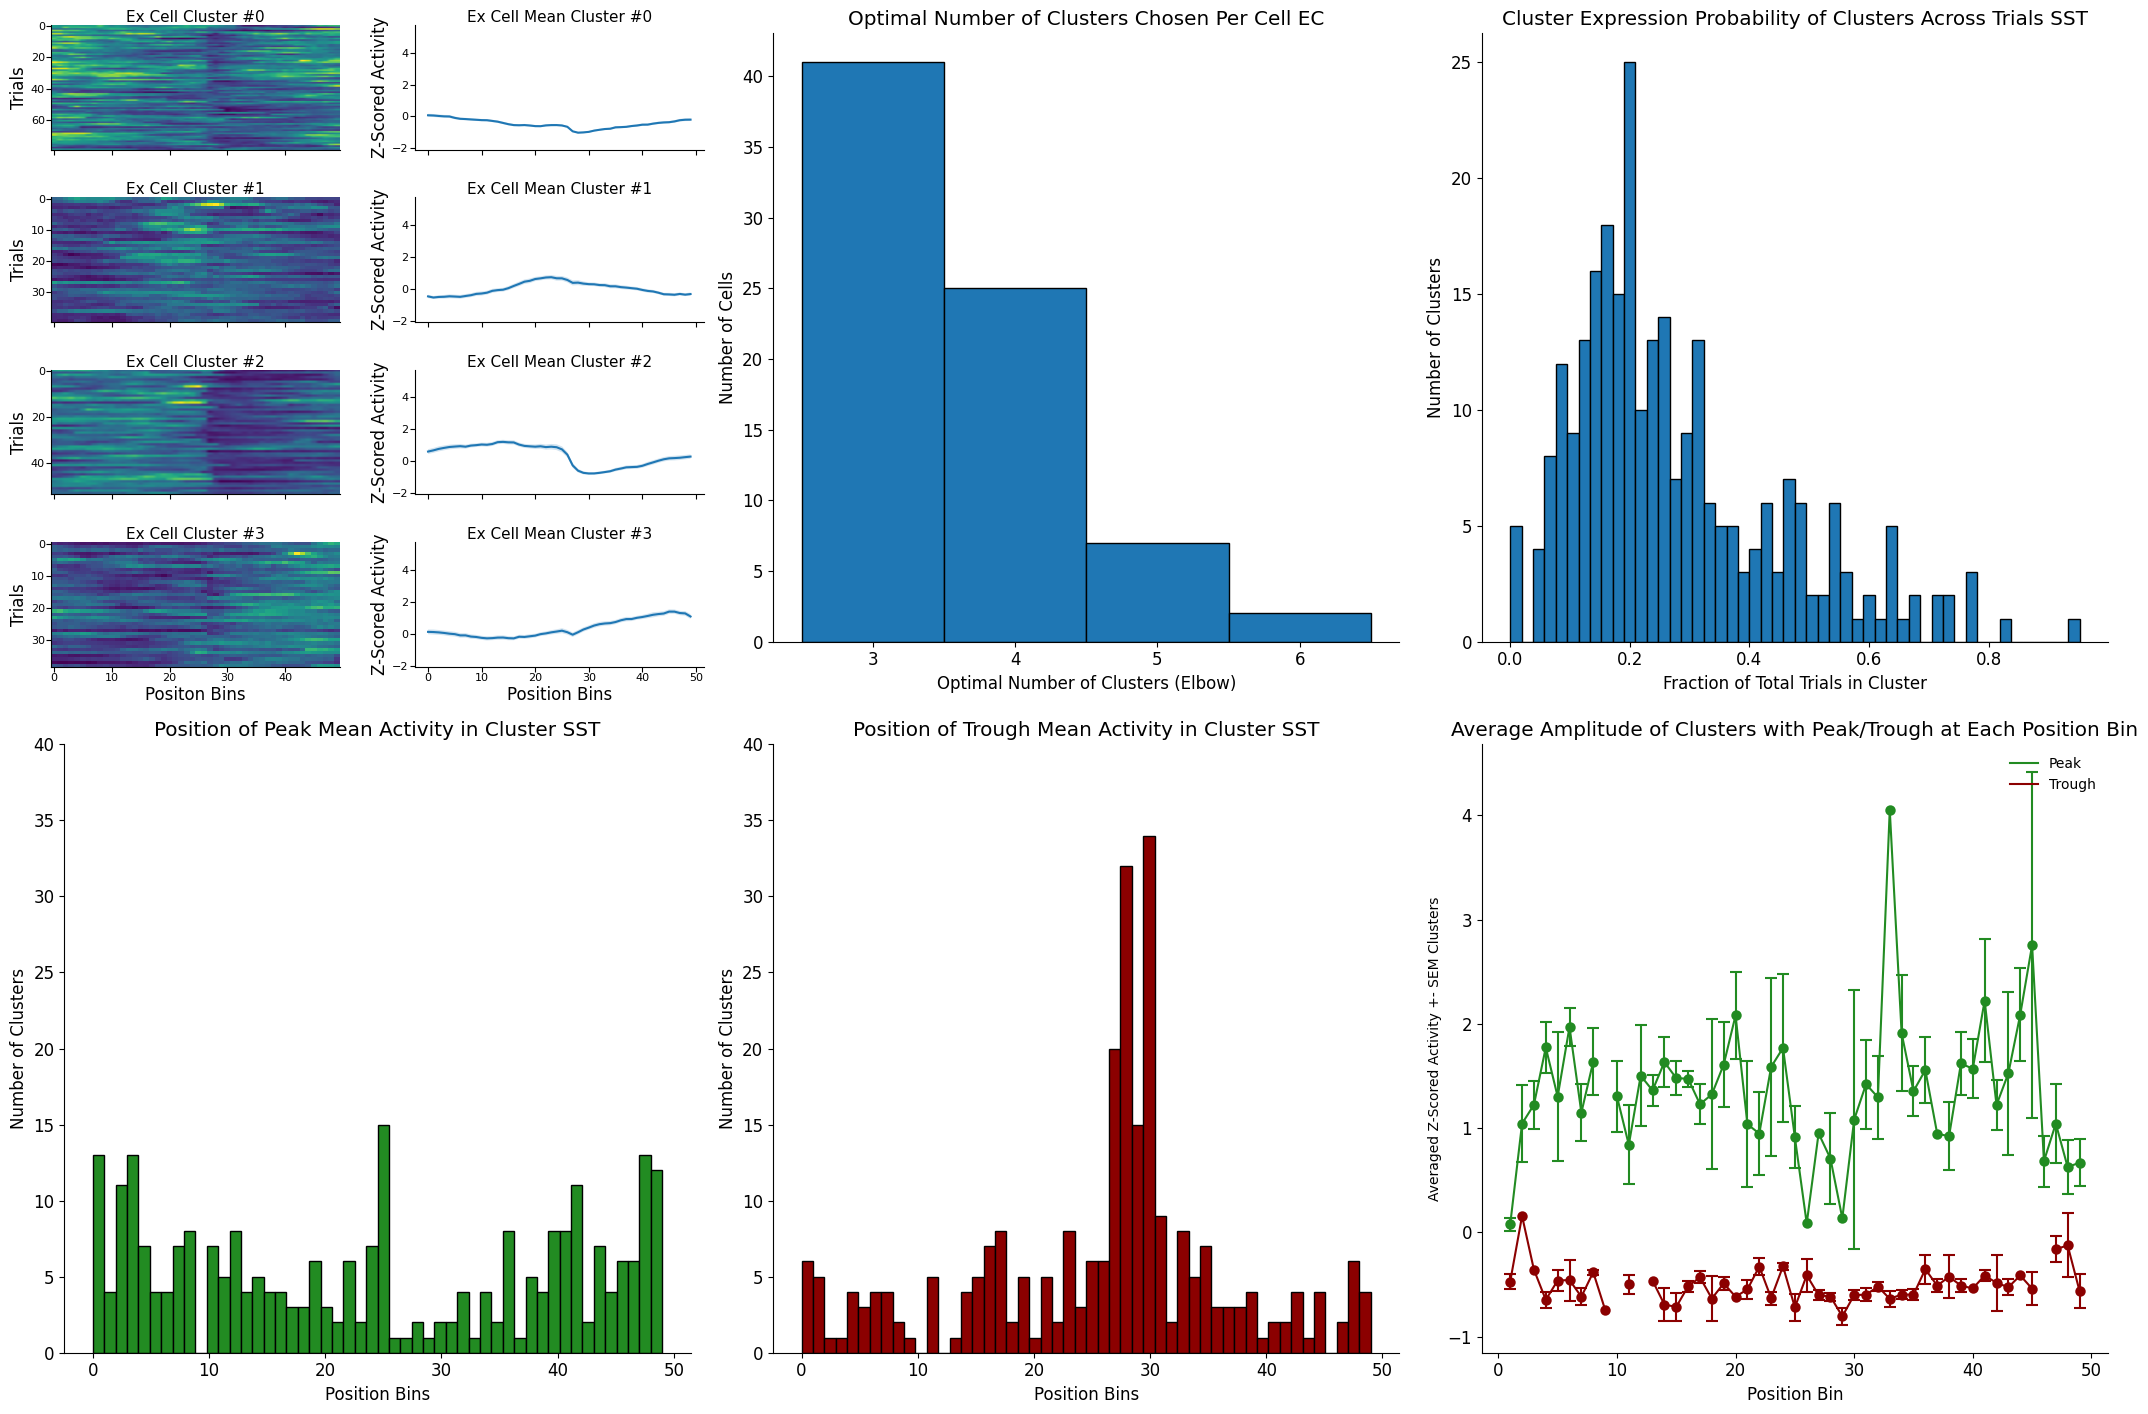

In [73]:
plot_pop_stats(clusters_dict_SST_overall, cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, cell_type="SST", animal='animal_1', cell='cell_2', ylim=(0,40))

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:521: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  "sem": sem(peak_per_cluster_list)}


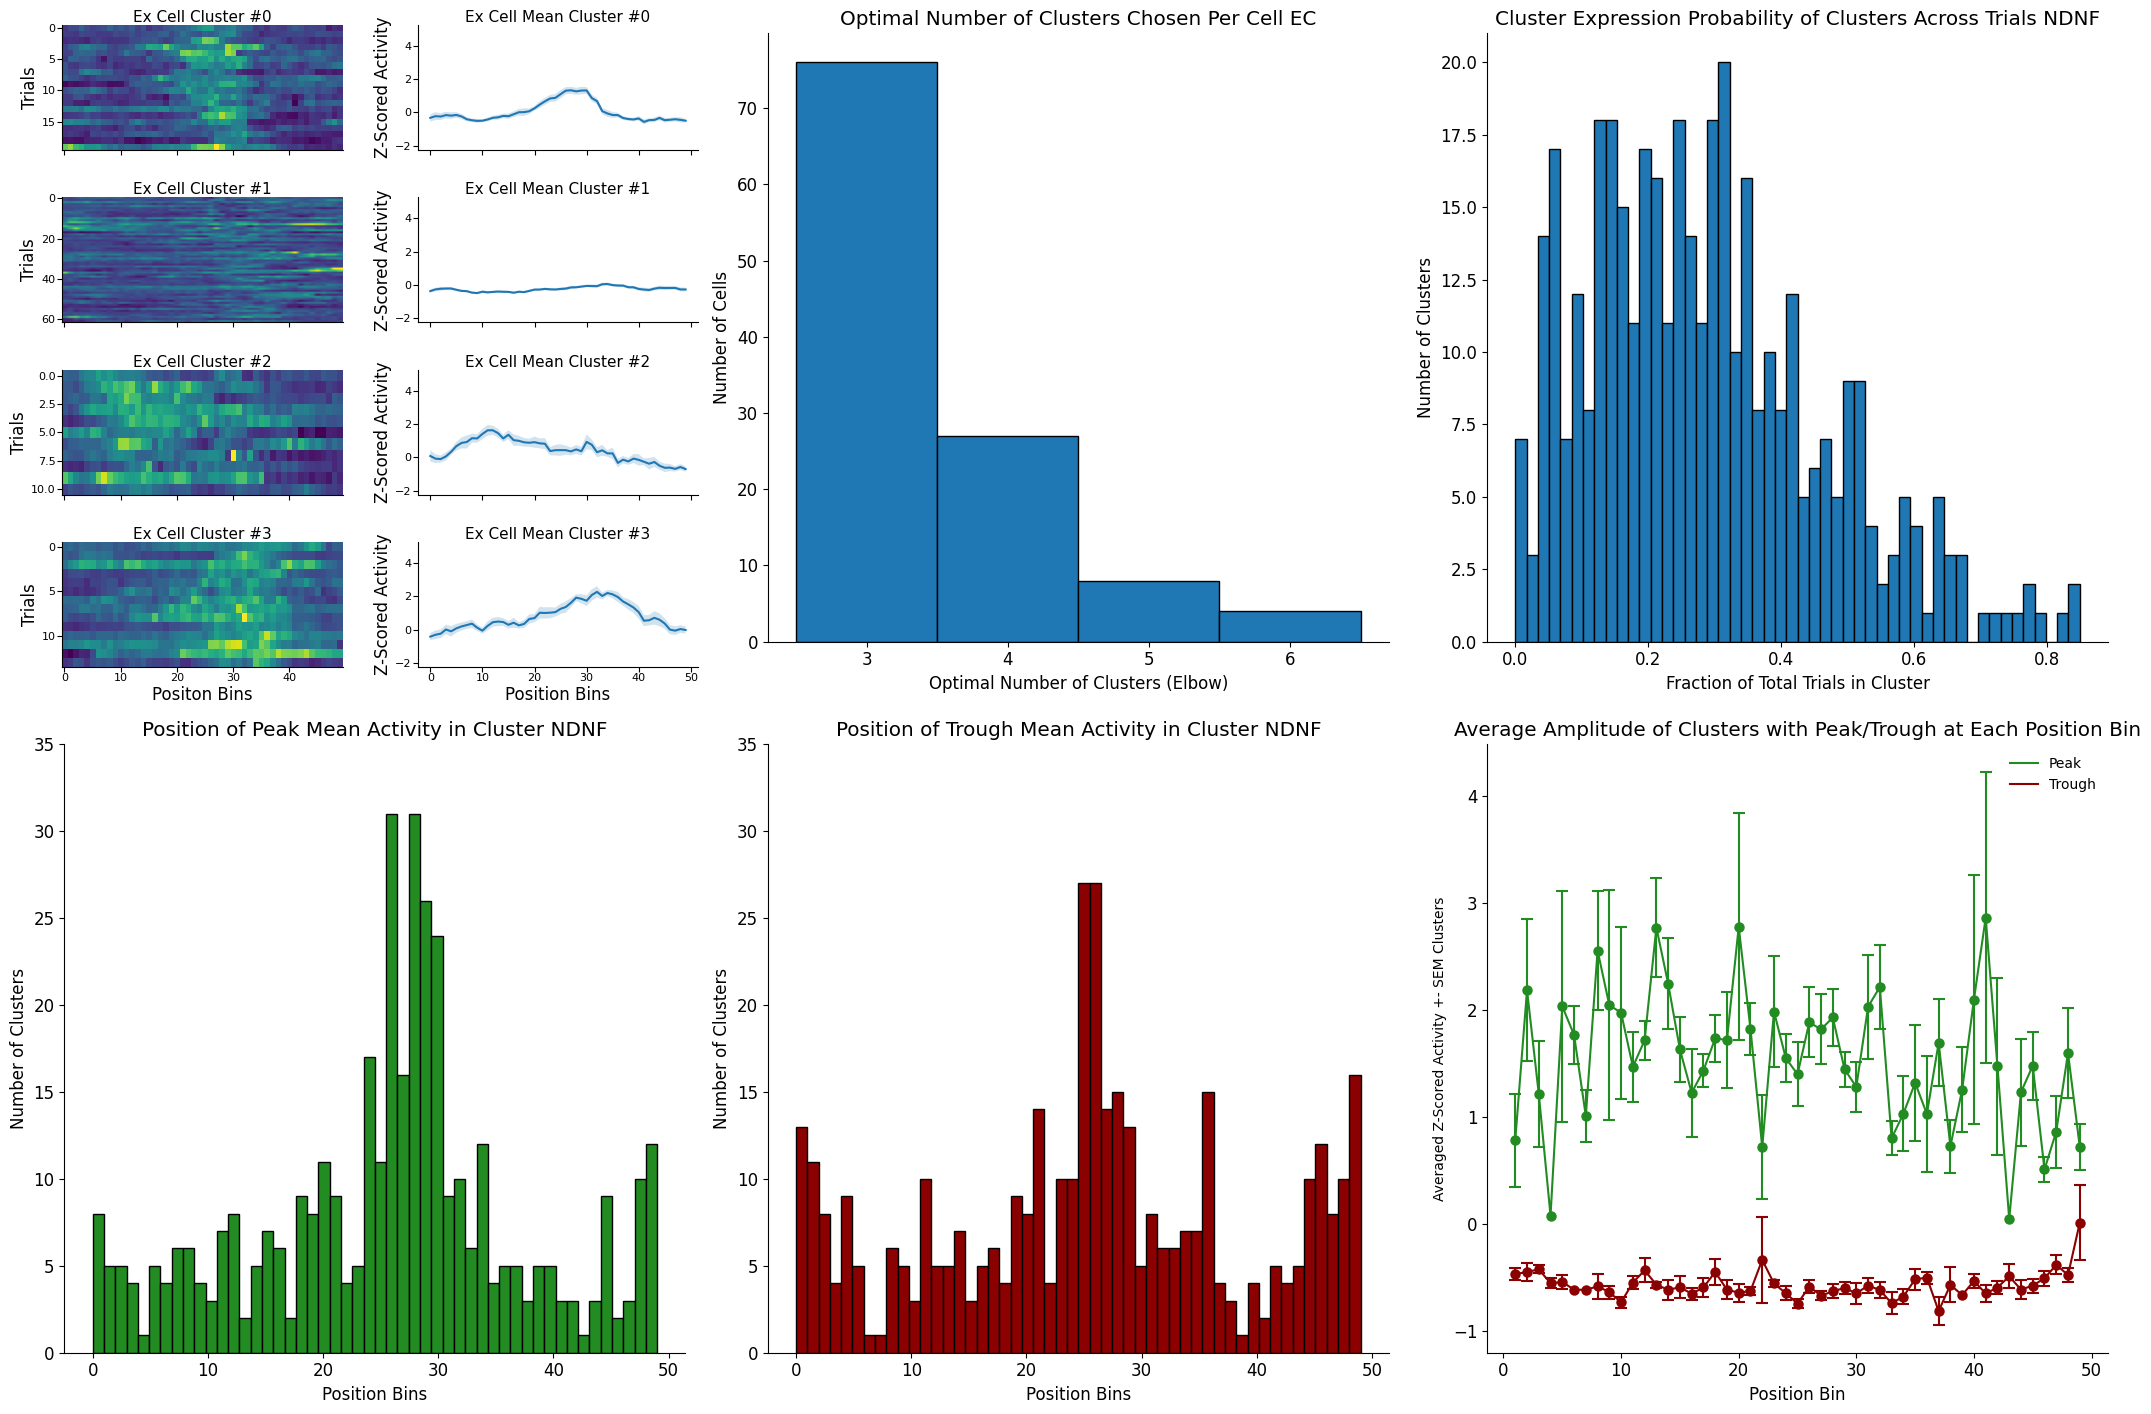

In [80]:
plot_pop_stats(clusters_dict_NDNF_overall, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, cell_type="NDNF", animal='animal_19', cell='cell_3', ylim=(0,35))

In [ ]:
def plot_means_sems_max_min(activity_indices_EC_dict, ax=None):
    mean_data_by_peak, max_bin = get_data_by_peak(activity_indices_EC_dict, use_peak=True)
    mean_data_by_trough, min_bin = get_data_by_peak(activity_indices_EC_dict, use_peak=False)

    means_peak, sems_peak = mean_sems_peak_trough(mean_data_by_peak, max_bin, use_peak=True)
    means_trough, sems_trough = mean_sems_peak_trough(mean_data_by_trough, min_bin, use_peak=False)

    x = np.arange(max_bin)
    ax.plot(means_peak, color="forestgreen", label="Peak")
    ax.errorbar(x, means_peak, yerr=sems_peak, fmt='o', capsize=4, elinewidth=1.5, markeredgewidth=1.5, color='forestgreen')
    ax.plot(means_trough, color="darkred", label="Trough")
    ax.errorbar(x, means_trough, yerr=sems_trough, fmt='o', capsize=4, elinewidth=1.5, markeredgewidth=1.5, color='darkred')
    ax.set_xlabel('Position Bin')
    ax.set_ylabel('Averaged Z-Scored Activity +- SEM Clusters', fontsize=10)
    ax.set_title('Average Amplitude of Clusters with Peak/Trough at Each Position Bin')
    ax.legend(fontsize=10, loc='upper right')



activity_indices_EC_dict['animal_1']['cell_1'].keys()

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/SliceTCA_example.py:470: RuntimeWarning: Mean of empty slice
  "mean_activity": np.nanmean(residual_activity_dict_EC[animal][cell][:,cluster_indices], axis=1)}


dict_keys([0, 1, 2, 3])

In [94]:
len(mean_data_by_peak)

50

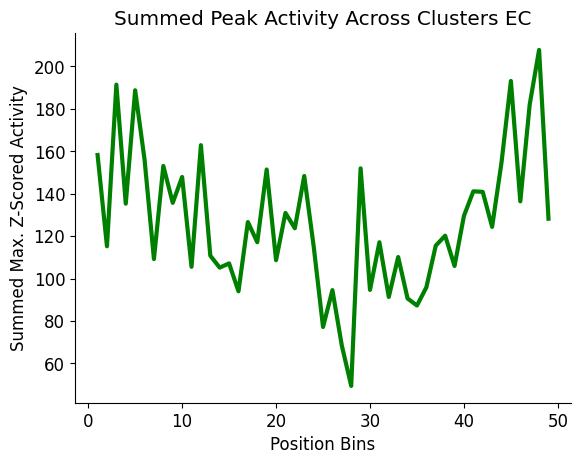

In [124]:
def mean_list(mean_data_by_peak):
    mean_max_list_per_pos = []

    for i in range(len(mean_data_by_peak)):
        max_list = []
        for j in range(len(mean_data_by_peak[i])):
            max_list.append(np.max(mean_data_by_peak[i][j]))


        mean_max_list = sum(max_list)
        # print(mean_max_list)
        mean_max_list_per_pos.append(mean_max_list)

    return mean_max_list_per_pos

def plot_the_sum(activity_indices_EC_dict, color=None, cell_type=None):
    mean_data_by_peak, max_bin = get_data_by_peak(activity_indices_EC_dict, use_peak=True)
    mean_data_by_trough, min_bin = get_data_by_peak(activity_indices_EC_dict, use_peak=False)

    mean_max_list_per_pos = mean_list(mean_data_by_peak)
    mean_min_list_per_pos = mean_list(mean_data_by_trough)

    plt.plot(mean_max_list_per_pos, color=color, linewidth=3)
    plt.ylabel("Summed Max. Z-Scored Activity")
    plt.xlabel("Position Bins")
    plt.title(f"Summed Peak Activity Across Clusters {cell_type}")

    # fig, axs = plt.subplots(2,1)
    # axs[0].plot(mean_max_list_per_pos, color=color, linewidth=3)
    # axs[0].set_ylabel("Summed Max. Z-Scored Activity")
    # axs[0].set_xlabel("Position Bins")
    # axs[0].set_title(f"Summed Peak Activity Across Clusters {cell_type}")


    # axs[1].plot(mean_min_list_per_pos, color=color, linewidth=3)
    # axs[1].set_ylabel("Summed Min. Z-Scored Activity")
    # axs[0].set_xlabel("Position Bins")
    # axs[0].set_title(f"Summed Trough Activity Across Clusters {cell_type}")


indices_dict_EC_overall = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
activity_indices_EC_dict = get_activity_from_indices(residual_activity_dict_EC, indices_dict_EC_overall)

plot_the_sum(activity_indices_EC_dict, color="green", cell_type="EC")


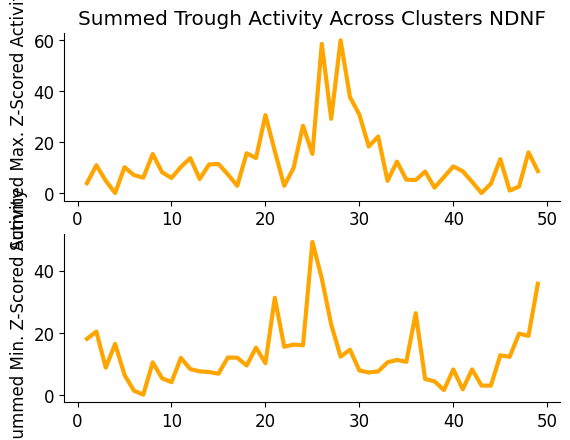

In [121]:

indices_dict_NDNF_overall = get_indices_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")
activity_indices_NDNF_dict = get_activity_from_indices(fixed_residual_activity_dict_NDNF_newest, indices_dict_NDNF_overall)

plot_the_sum(activity_indices_NDNF_dict, color="orange", cell_type="NDNF")


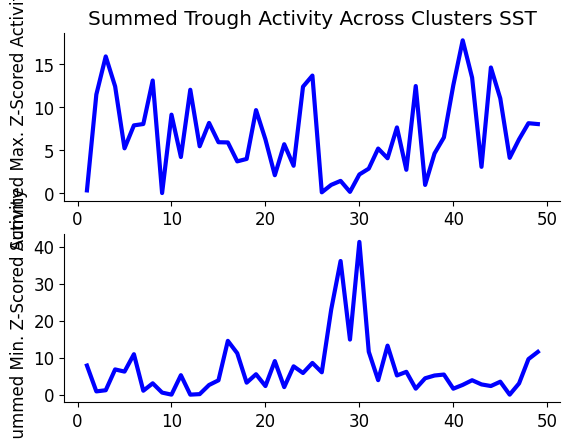

In [122]:
indices_dict_SST_overall = get_indices_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")
activity_indices_SST_dict = get_activity_from_indices(residual_activity_dict_SST, indices_dict_SST_overall)

plot_the_sum(activity_indices_SST_dict, color="blue", cell_type="SST")